# Include all of the libraries and ensure file connections are working between each other

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

while not (
    (PROJECT_ROOT / "Detection").exists()
    and (PROJECT_ROOT / "Image-Preprocessing").exists()
    and (PROJECT_ROOT / "Ground-Truth").exists()
    and (PROJECT_ROOT / "QD-Analysis").exists()
):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root.")

    PROJECT_ROOT = PROJECT_ROOT.parent


DETECTION_DIR = PROJECT_ROOT / "Detection"
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"
GROUND_TRUTH_DIR = PROJECT_ROOT / "Ground-Truth"
QD_ANALYSIS_DIR = PROJECT_ROOT / "QD-Analysis"

CLASSICAL_DIR = DETECTION_DIR / "Classical-Optimised"
BIOLOGY_DIR = DETECTION_DIR / "Biology-Inspired"
CNN_DIR = DETECTION_DIR / "Binary-Unet"


for path in [
    PROJECT_ROOT,
    DETECTION_DIR,
    PREPROCESSING_DIR,
    GROUND_TRUTH_DIR,
    QD_ANALYSIS_DIR,
    CLASSICAL_DIR,
    BIOLOGY_DIR,
    CNN_DIR,
]:
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import preprocessing_metrics as pm

import detection_algorithms as da
import detection_errors as de

import QD_analysis as qa
import feature_evaluation as fe

import rf_model as rfm

Include the new libraries:

In [2]:
from sklearn.ensemble import RandomForestClassifier
from scipy.ndimage import gaussian_filter, gaussian_laplace, sobel, uniform_filter
from skimage.morphology import remove_small_objects
import numpy as np

# Train the random forest based on the scans 

In [3]:
scans = {}

for scan_name in ["Scan1", "Scan2", "Scan3"]:
    scan_folder = GROUND_TRUTH_DIR / "NPY-Ground-Truth" / scan_name

    raw = np.load(scan_folder / "channel_00___0_data.npy")
    mask = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)

    processed, _ = bdp.preprocess_afm(raw, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
    processed = bdp.robust_normalise(processed).astype(np.float32)

    scans[scan_name] = {"image": processed, "mask": mask}

rng = np.random.default_rng(50)

X_parts = []
y_parts = []

for scan_name in ["Scan1", "Scan2"]:
    image = scans[scan_name]["image"]
    mask = scans[scan_name]["mask"]

    features = rfm.rf_pixel_features(image)

    X_all = features.reshape(-1, features.shape[-1])
    y_all = mask.ravel().astype(np.uint8)

    positive_idx = np.where(y_all == 1)[0]
    negative_idx = np.where(y_all == 0)[0]

    n_negative = min(len(negative_idx), 4 * len(positive_idx))
    negative_idx = rng.choice(negative_idx, size=n_negative, replace=False)

    selected = np.concatenate([positive_idx, negative_idx])

    X_parts.append(X_all[selected])
    y_parts.append(y_all[selected])

X_train = np.concatenate(X_parts)
y_train = np.concatenate(y_parts)

print("Training samples:", len(y_train))
print("QD pixels:", y_train.sum())
print("Background pixels:", len(y_train) - y_train.sum())

Training samples: 59615
QD pixels: 11923
Background pixels: 47692.0


The random forest doesnt understand image structure by itself. It just sees the row of numbers. So, rf_pixel_features converts each pixel into a table:

one pixel → [height, smoothed height, LoG response, gradient, local mean, local std, ...]

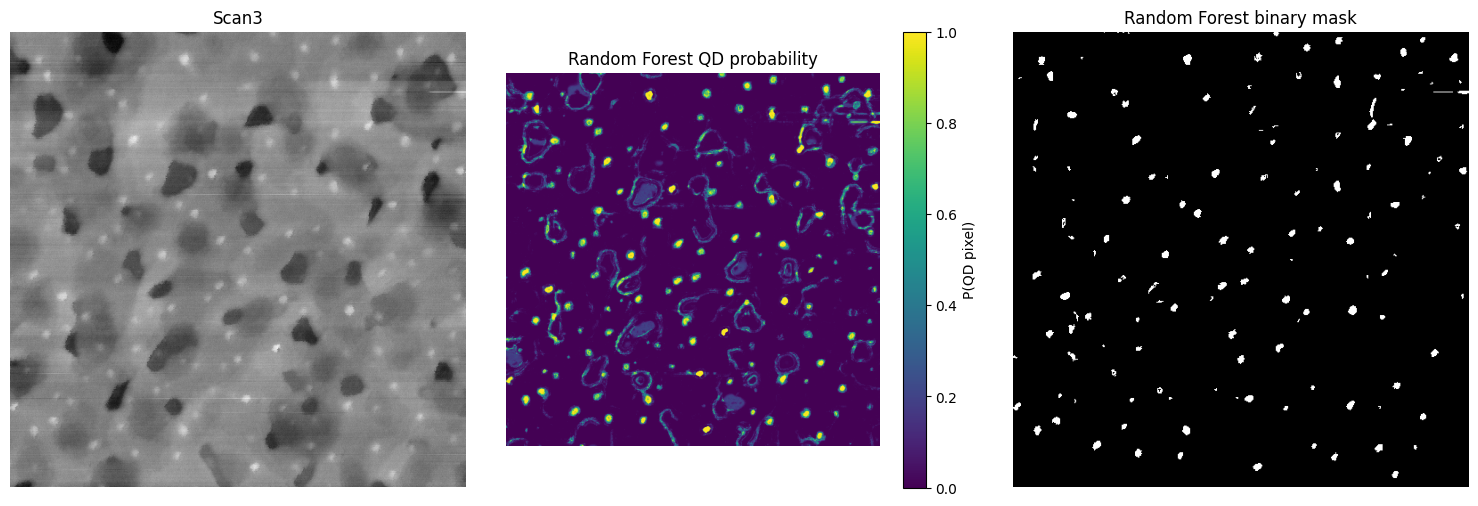

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

scan3_image = scans["Scan3"]["image"]
scan3_gt = scans["Scan3"]["mask"]

scan3_features = rfm.rf_pixel_features(scan3_image)
X_scan3 = scan3_features.reshape(-1, scan3_features.shape[-1])

rf_probability = rf.predict_proba(X_scan3)[:, 1].reshape(scan3_image.shape)
rf_mask = rf_probability >= 0.7

rf_mask = remove_small_objects(rf_mask, min_size=5)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(scan3_image, cmap="gray")
axes[0].set_title("Scan3")

im = axes[1].imshow(rf_probability, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Random Forest QD probability")

axes[2].imshow(rf_mask, cmap="gray")
axes[2].set_title("Random Forest binary mask")

for ax in axes:
    ax.axis("off")

fig.colorbar(im, ax=axes[1], label="P(QD pixel)")
plt.tight_layout()
plt.show()

## Evaluate Random forest

In [5]:
rf_metrics = fe.evaluate_feature_masks(scan3_gt, rf_mask, tolerance=3.0)

display(pd.DataFrame([rf_metrics], index=["Random Forest"]))

,TP,FP,FN,GT count,Predicted count,Precision,Recall,F1
Random Forest,92,45,46,138,137,0.671533,0.666667,0.669091


Importance of the porperties selected by Random Forest

In [6]:
feature_names = [
    "height",
    "Gaussian σ=1",
    "Gaussian σ=2",
    "Gaussian σ=4",
    "LoG σ=1",
    "LoG σ=2",
    "gradient",
    "local mean",
    "local std",
]

importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

display(importance)

LoG σ=2         0.377496
local std       0.238641
Gaussian σ=1    0.119844
height          0.113647
Gaussian σ=2    0.045938
LoG σ=1         0.035826
gradient        0.029525
Gaussian σ=4    0.022446
local mean      0.016637
dtype: float64

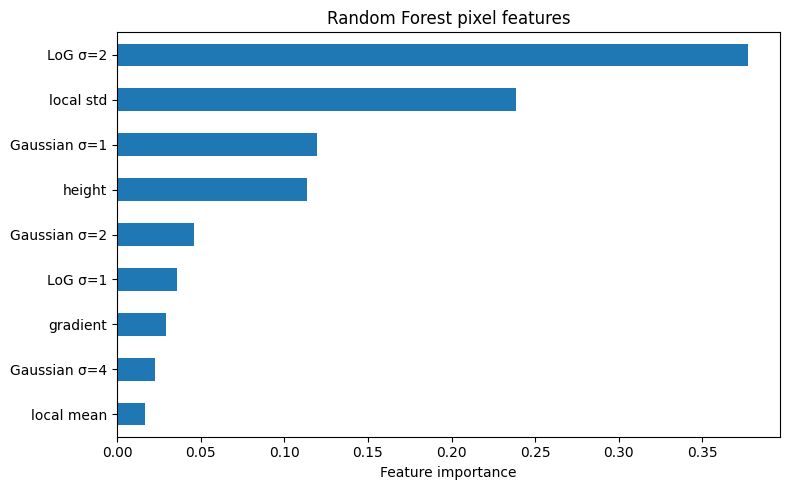

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
importance.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest pixel features")
plt.tight_layout()
plt.show()

In [8]:
rf_prob_smooth, rf_mask_smooth = rfm.smooth_rf_mask(
    rf_probability,
    threshold=0.61,
    prob_sigma=1.2,
    close_radius=2,
    open_radius=1,
    min_area=6,
    max_area=120,
    min_solidity=0.55,
    max_eccentricity=0.95,
)

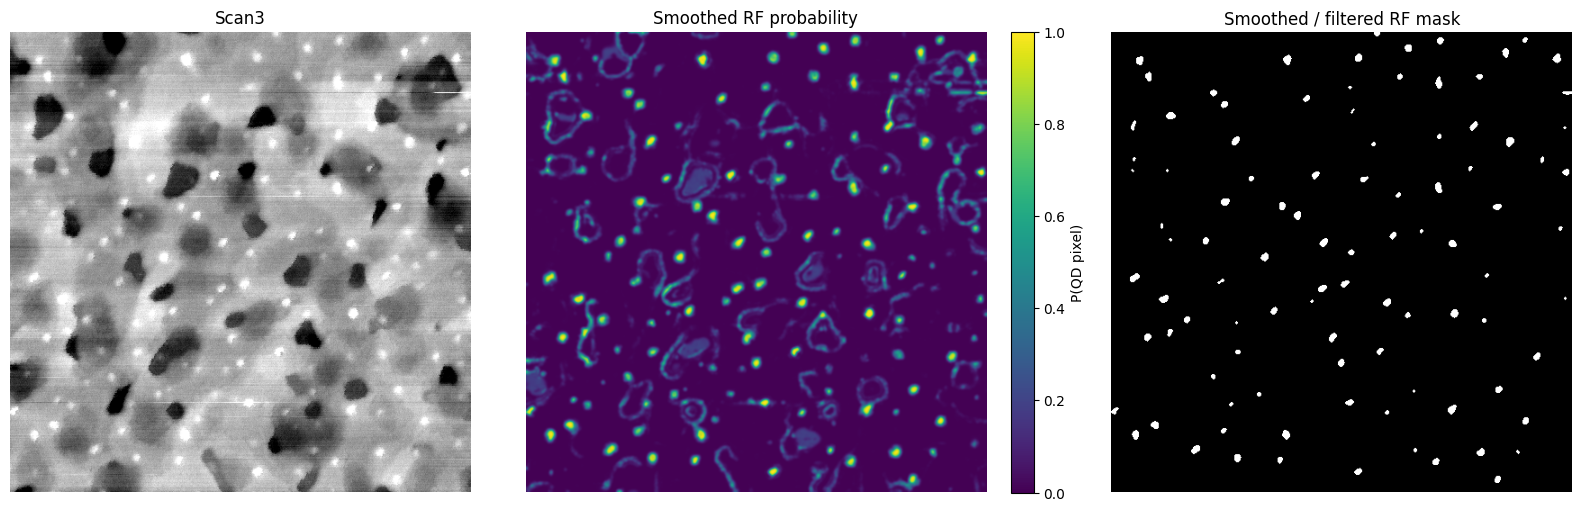

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

vmin, vmax = np.nanpercentile(scan3_image, [1, 99])

axes[0].imshow(scan3_image, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Scan3")
axes[0].axis("off")

im = axes[1].imshow(rf_prob_smooth, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Smoothed RF probability")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], label="P(QD pixel)")

axes[2].imshow(rf_mask_smooth, cmap="gray")
axes[2].set_title("Smoothed / filtered RF mask")
axes[2].axis("off")

plt.show()

In [10]:
rf_metrics = fe.evaluate_feature_masks(scan3_gt, rf_mask_smooth, tolerance=3.0)

display(pd.DataFrame([rf_metrics], index=["Random Forest"]))

,TP,FP,FN,GT count,Predicted count,Precision,Recall,F1
Random Forest,83,14,55,138,97,0.85567,0.601449,0.706383


but this may be because lots of points are sampled randomly, so when they are at the edge of the pit, random forest thinks this is a special point.. so I should do some negative sampling.

In [21]:
import QD_analysis as qa
import rf_model as rfm

from sklearn.ensemble import RandomForestClassifier
from skimage.morphology import remove_small_objects

scans = {}

for scan_name in ["Scan1", "Scan2", "Scan3"]:
    scan_folder = GROUND_TRUTH_DIR / "NPY-Ground-Truth" / scan_name

    raw = np.load(scan_folder / "channel_00___0_data.npy")
    gt_mask = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)

    processed, _ = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    processed, stripe_map_2d = bdp.remove_partial_horizontal_stripes(
    processed,
    sigma_x=40,
    sigma_y_small=2.0,
    sigma_y_large=12.0,
    strength=0.75,
    )

    processed -= np.nanmedian(processed)

    gan_mask = qa.create_gan_mask(processed)
    image = bdp.robust_normalise(processed).astype(np.float32)

    scans[scan_name] = {
        "image": image,
        "processed": processed,
        "mask": gt_mask,
        "gan_mask": gan_mask,
    }

In [22]:
rng = np.random.default_rng(50)

X_parts = []
y_parts = []

for scan_name in ["Scan1", "Scan2"]:
    image = scans[scan_name]["image"]
    gt_mask = scans[scan_name]["mask"]
    gan_mask = scans[scan_name]["gan_mask"]

    features = rfm.rf_pixel_features_mask(image, gan_mask)

    X_all = features.reshape(-1, features.shape[-1])
    y_all = gt_mask.ravel().astype(np.uint8)

    positive_idx = np.where(y_all == 1)[0]
    negative_idx = np.where(y_all == 0)[0]

    n_negative = min(len(negative_idx), 4 * len(positive_idx))
    negative_idx = rng.choice(negative_idx, size=n_negative, replace=False)

    selected = np.concatenate([positive_idx, negative_idx])

    X_parts.append(X_all[selected])
    y_parts.append(y_all[selected])

X_train = np.concatenate(X_parts)
y_train = np.concatenate(y_parts)

print("Training shape:", X_train.shape)

Training shape: (59615, 11)


In [23]:
rf = RandomForestClassifier(
    n_estimators=450,
    max_depth=15,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=50,
)

rf.fit(X_train, y_train)

print("RF expects:", rf.n_features_in_, "features")

RF expects: 11 features


In [24]:
scan3_image = scans["Scan3"]["image"]
scan3_gt = scans["Scan3"]["mask"]
scan3_gan_mask = scans["Scan3"]["gan_mask"]

scan3_features = rfm.rf_pixel_features_mask(
    scan3_image,
    scan3_gan_mask,
)

X_scan3 = scan3_features.reshape(-1, scan3_features.shape[-1])

print("Scan3 feature shape:", X_scan3.shape)

rf_probability = rf.predict_proba(X_scan3)[:, 1].reshape(scan3_image.shape)

rf_mask = rf_probability >= 0.8
rf_mask = remove_small_objects(rf_mask, min_size=5)

Scan3 feature shape: (262144, 11)


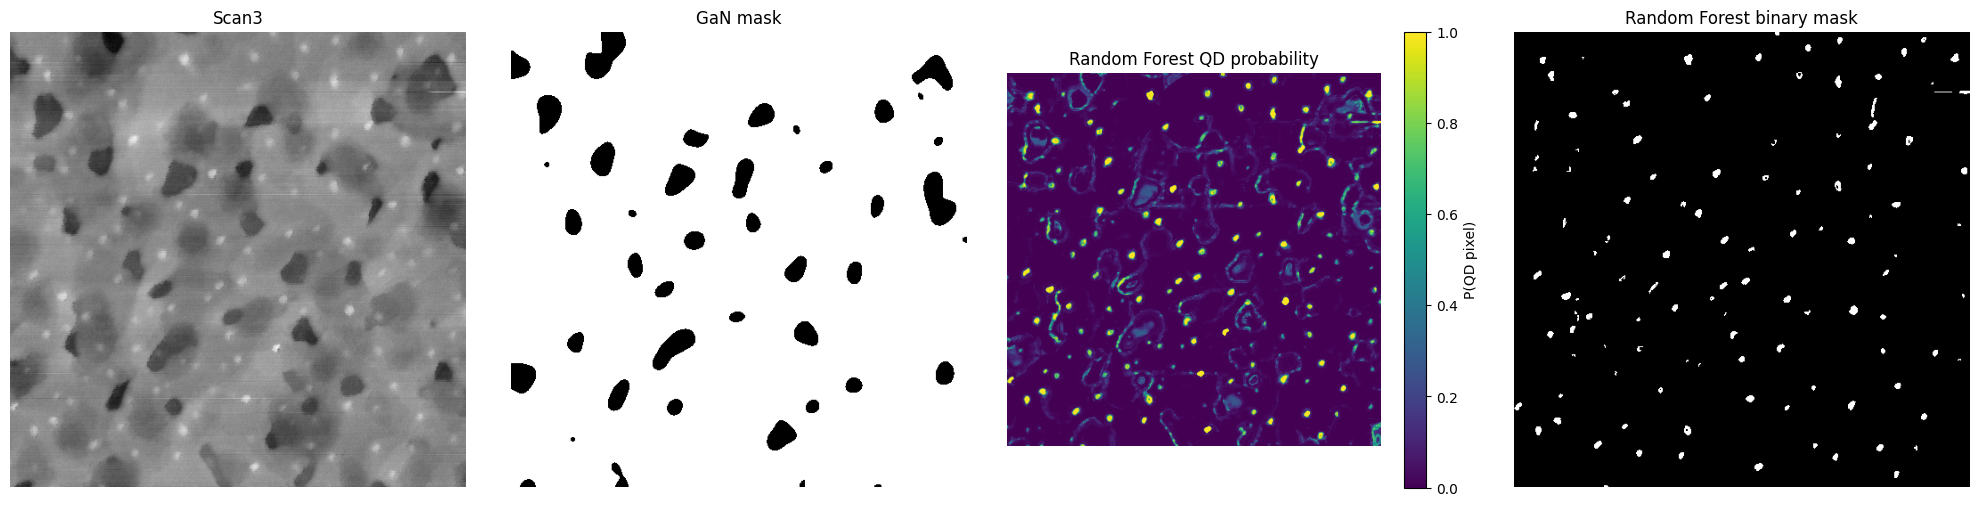

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(scan3_image, cmap="gray")
axes[0].set_title("Scan3")

axes[1].imshow(scan3_gan_mask, cmap="gray")
axes[1].set_title("GaN mask")

im = axes[2].imshow(rf_probability, cmap="viridis", vmin=0, vmax=1)
axes[2].set_title("Random Forest QD probability")

axes[3].imshow(rf_mask, cmap="gray")
axes[3].set_title("Random Forest binary mask")

for ax in axes:
    ax.axis("off")

fig.colorbar(im, ax=axes[2], label="P(QD pixel)")

plt.tight_layout()
plt.show()

In [26]:
rf_metrics = fe.evaluate_feature_masks(scan3_gt, rf_mask_smooth, tolerance=3.0)

display(pd.DataFrame([rf_metrics], index=["Random Forest"]))

,TP,FP,FN,GT count,Predicted count,Precision,Recall,F1
Random Forest,83,14,55,138,97,0.85567,0.601449,0.706383
